## **Notebook 3: `Job Categories & Trend Analysis`**


## **1. Importing libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## **2. Loading cleaned data**

In [2]:
df = pd.read_csv(r"D:\Project 8\cleaned_jobs.csv")
df["published_date"] = pd.to_datetime(df["published_date"])

## **3. Assign Category by tittle**

In [3]:
def map_category(title):
    title = str(title).lower()
    
    if any(k in title for k in ["data analyst", "data science", "machine learning", "ai", "python", "sql"]):
        return "AI_ML_Data"
    elif any(k in title for k in ["wordpress", "web developer", "php", "javascript", "react", "frontend", "backend"]):
        return "Web_Development"
    elif any(k in title for k in ["seo", "marketing", "social media", "ads", "lead generation"]):
        return "Marketing_SEO"
    elif any(k in title for k in ["graphic", "designer", "ui", "ux", "video editing", "logo"]):
        return "Design_Creative"
    elif any(k in title for k in ["virtual assistant", "data entry", "admin", "support"]):
        return "Admin_Support"
    elif any(k in title for k in ["blockchain", "web3", "crypto", "nft"]):
        return "Blockchain_Web3"
    elif any(k in title for k in ["mobile app", "android", "ios", "flutter"]):
        return "Mobile_Development"
    else:
        return "Other"

df["category"] = df["clean_title"].apply(map_category)

## **4. Creating monthly counts**

In [4]:
monthly_category = (
    df.groupby(["year_month", "category"])
      .size()
      .reset_index(name="job_count")
)
monthly_category.head()

,year_month,category,job_count
0,2023-11,Other,1
1,2023-12,AI_ML_Data,2
2,2023-12,Design_Creative,1
3,2023-12,Marketing_SEO,2
4,2023-12,Other,5


## **5. Pivot for trend view**

In [5]:
category_pivot = monthly_category.pivot(index="year_month", columns="category", values="job_count").fillna(0)
category_pivot

category,AI_ML_Data,Admin_Support,Blockchain_Web3,Design_Creative,Marketing_SEO,Mobile_Development,Other,Web_Development
year_month,,,,,,,,
2023-11,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2023-12,2.0,0.0,0.0,1.0,2.0,0.0,5.0,0.0
2024-01,7.0,9.0,0.0,10.0,9.0,2.0,59.0,0.0
2024-02,9969.0,3208.0,511.0,12676.0,9624.0,1662.0,59440.0,4797.0
2024-03,13997.0,3647.0,955.0,17934.0,14146.0,2279.0,82853.0,7023.0


## **6. Growth analysis**

In [6]:
growth_summary = []

for category in category_pivot.columns:
    first = category_pivot[category].iloc[0]
    last = category_pivot[category].iloc[-1]
    growth_pct = ((last - first) / first * 100) if first != 0 else np.nan
    
    growth_summary.append({
        "category": category,
        "first_month_count": first,
        "last_month_count": last,
        "growth_pct": growth_pct
    })

growth_df = pd.DataFrame(growth_summary).sort_values("growth_pct", ascending=False)
growth_df

,category,first_month_count,last_month_count,growth_pct
6,Other,1.0,82853.0,8285200.0
0,AI_ML_Data,0.0,13997.0,NaN
1,Admin_Support,0.0,3647.0,NaN
2,Blockchain_Web3,0.0,955.0,NaN
3,Design_Creative,0.0,17934.0,NaN
4,Marketing_SEO,0.0,14146.0,NaN
5,Mobile_Development,0.0,2279.0,NaN
7,Web_Development,0.0,7023.0,NaN


## **7. Trend visualization**

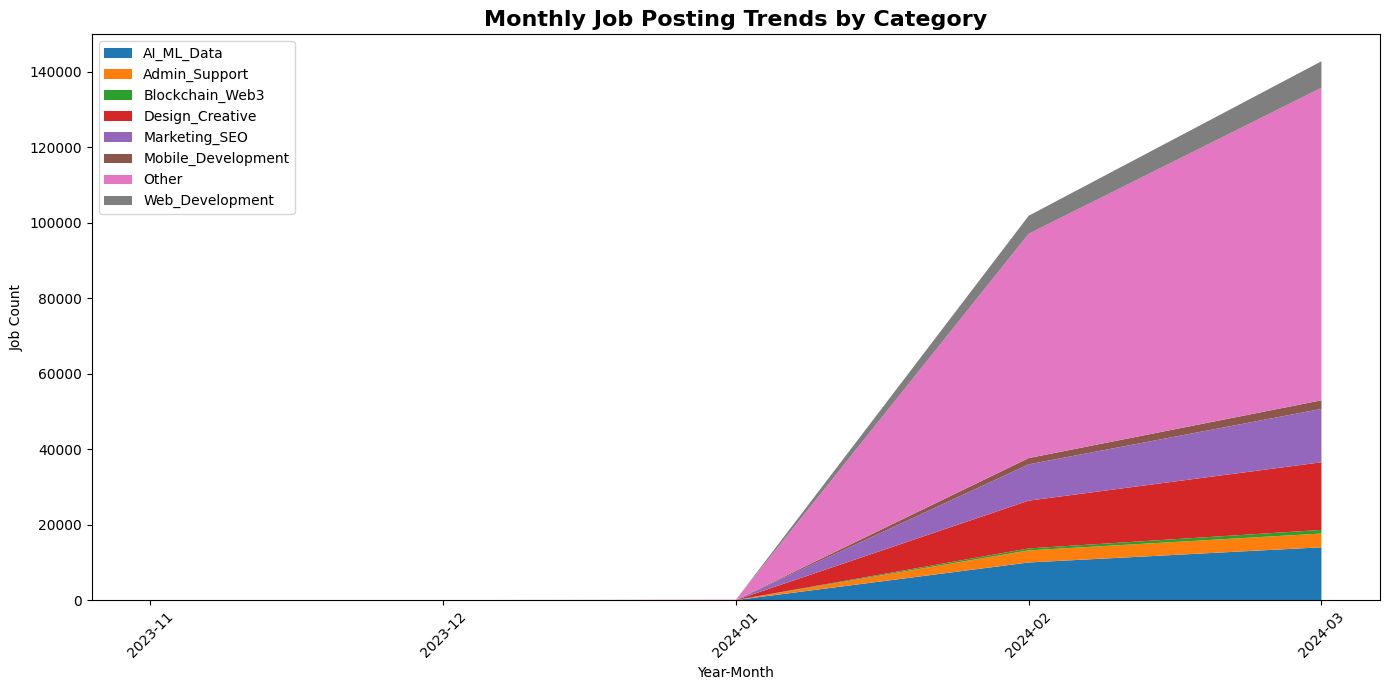

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.stackplot(
    category_pivot.index,
    category_pivot.T,  # transpose for stackplot
    labels=category_pivot.columns
)

plt.title("Monthly Job Posting Trends by Category", fontsize=16, weight='bold')
plt.xlabel("Year-Month")
plt.ylabel("Job Count")

plt.xticks(rotation=45)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## **8. Emerging categories**

In [8]:
emerging_categories = growth_df[growth_df["growth_pct"] > 0]
emerging_categories

,category,first_month_count,last_month_count,growth_pct
6,Other,1.0,82853.0,8285200.0


## **9. Exporting results**

In [10]:
df.to_csv("category_jobs.csv", index=False)
monthly_category.to_csv("monthly_trends.csv", index=False)
growth_df.to_csv("category_growth_summary.csv", index=False)